In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [ ]:
path = 'Tweets.csv'
parent_df=pd.read_csv(path)
parent_df.head(),parent_df.shape

(             tweet_id airline_sentiment  airline_sentiment_confidence  \
 0  570306133677760513           neutral                        1.0000   
 1  570301130888122368          positive                        0.3486   
 2  570301083672813571           neutral                        0.6837   
 3  570301031407624196          negative                        1.0000   
 4  570300817074462722          negative                        1.0000   
 
   negativereason  negativereason_confidence         airline  \
 0            NaN                        NaN  Virgin America   
 1            NaN                     0.0000  Virgin America   
 2            NaN                        NaN  Virgin America   
 3     Bad Flight                     0.7033  Virgin America   
 4     Can't Tell                     1.0000  Virgin America   
 
   airline_sentiment_gold        name negativereason_gold  retweet_count  \
 0                    NaN     cairdin                 NaN              0   
 1              

In [ ]:
df=parent_df[['airline_sentiment','text']]
df.head()

,airline_sentiment,text
0,neutral,@VirginAmerica What @dhepburn said.
1,positive,@VirginAmerica plus you've added commercials t...
2,neutral,@VirginAmerica I didn't today... Must mean I n...
3,negative,@VirginAmerica it's really aggressive to blast...
4,negative,@VirginAmerica and it's a really big bad thing...


In [ ]:
df['airline_sentiment'].unique()

array(['neutral', 'positive', 'negative'], dtype=object)

In [ ]:
df.shape

(14640, 2)

TEXT CLEANING

In [ ]:
import re
import html

def clean_text_for_audit(text):
    if not isinstance(text, str):
        return ""

    # 1. Decode HTML entities (e.g., &amp; -> &)
    text = html.unescape(text)

    # 2. Remove URLs and Email addresses
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)

    # 3. Remove weird whitespace but keep newlines as spaces
    text = text.replace('\n', ' ').replace('\r', ' ').replace('\t', ' ')

    # 4. Remove non-printable characters
    text = "".join(char for char in text if char.isprintable())

    # 5. Normalize multiple spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Apply to your DataFrame
df['clean_text'] = df['text'].apply(clean_text_for_audit)

# Deduplication (Crucial: same text with different labels is an automatic error)
df = df.drop_duplicates(subset=['clean_text', 'airline_sentiment'])##removes rows where both the cleaned text AND sentiment label are identical.
print(f"Data cleaned. Remaining samples: {len(df)}")

Data cleaned. Remaining samples: 14419


/tmp/ipython-input-198652068.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['clean_text'] = df['text'].apply(clean_text_for_audit)


In [ ]:
df.shape

(14419, 3)

In [ ]:
df.head()

,airline_sentiment,text,clean_text
0,neutral,@VirginAmerica What @dhepburn said.,@VirginAmerica What @dhepburn said.
1,positive,@VirginAmerica plus you've added commercials t...,@VirginAmerica plus you've added commercials t...
2,neutral,@VirginAmerica I didn't today... Must mean I n...,@VirginAmerica I didn't today... Must mean I n...
3,negative,@VirginAmerica it's really aggressive to blast...,@VirginAmerica it's really aggressive to blast...
4,negative,@VirginAmerica and it's a really big bad thing...,@VirginAmerica and it's a really big bad thing...


Text → Embeddings (Semantic Meaning)

In [ ]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-mpnet-base-v2")
embeddings = model.encode(
    df["clean_text"].tolist(),
    batch_size=32,
    convert_to_numpy=True,
    show_progress_bar=True
)
df["embedding"] = list(embeddings)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/451 [00:00<?, ?it/s]

In [ ]:
df.head()

,airline_sentiment,text,clean_text,embedding
0,neutral,@VirginAmerica What @dhepburn said.,@VirginAmerica What @dhepburn said.,"[-0.0155178225, 0.016140928, -0.0062406105, -0..."
1,positive,@VirginAmerica plus you've added commercials t...,@VirginAmerica plus you've added commercials t...,"[0.010883449, 0.070010535, -0.024289403, -0.05..."
2,neutral,@VirginAmerica I didn't today... Must mean I n...,@VirginAmerica I didn't today... Must mean I n...,"[-0.014241995, 0.02331738, -0.037859295, -0.02..."
3,negative,@VirginAmerica it's really aggressive to blast...,@VirginAmerica it's really aggressive to blast...,"[0.0075340234, 0.016004702, -0.01237896, 0.019..."
4,negative,@VirginAmerica and it's a really big bad thing...,@VirginAmerica and it's a really big bad thing...,"[0.025873858, 0.0136139095, -0.00562298, -0.04..."


OPTUNA FOR UMAP AND HDBSACN

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 13.0 MB/s eta 0:00:00


In [ ]:
import optuna

In [ ]:
!pip install umap-learn hdbscan scikit-learn


In [ ]:
import umap,hdbscan
from sklearn.metrics import silhouette_score

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


In [ ]:
  embeddings = np.stack(df['embedding'].values)  # Stack 1D → 2D
  print(embeddings.shape)  # Now (14419, 768)


(14419, 768)


In [ ]:
def objective(trial):
    # 1. UMAP: Focus on density (min_dist=0) and enough dimensions for nuance
    n_neighbors = trial.suggest_int('n_neighbors', 10, 50)# Local structure balance
    n_components = trial.suggest_int('n_components', 5, 30) # output dimensions range

    reducer = umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=0.0, # Keeps clusters tight for auditing
        n_components=n_components,
        metric='cosine',
        random_state=42,
        n_jobs=1
    )
    emb_reduced = reducer.fit_transform(embeddings)

    # 2. HDBSCAN: Let min_samples be smaller for more sensitivity
    min_cluster_size = trial.suggest_int('min_cluster_size', 10, 40)

    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=2, # Sensitivity to small groups
        metric='euclidean',
        prediction_data=True
    )
    labels = clusterer.fit_predict(emb_reduced)

    # 3. Enhanced Scoring logic
    # Filter out noise for the silhouette calculation
    mask = labels >= 0
    n_clusters = len(np.unique(labels[mask]))
    outlier_pct = np.sum(labels == -1) / len(labels)

    if n_clusters < 2 or outlier_pct > 0.3: # We don't want >30% noise
        return -2.0 # Heavy penalty

    # Calculate silhouette ONLY on clustered points
    sil = silhouette_score(emb_reduced[mask], labels[mask])

    # Objective: High silhouette, Low outliers, reasonable cluster count
    # We want clusters, but not 100 clusters (which would be over-fitting)
    score = sil - (outlier_pct * 2) + (0.05 * min(n_clusters, 20))

    return score

In [ ]:
# Create and run the study
study = optuna.create_study(direction="maximize",sampler=optuna.samplers.TPESampler(seed=42),study_name="Label_Audit_Optimization")
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"Best Score: {study.best_value}")
print(f"Best Hyperparameters: {study.best_params}")

[I 2026-02-25 09:02:52,830] A new study created in memory with name: Label_Audit_Optimization


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-02-25 09:03:29,144] Trial 0 finished with value: 1.1679177337979567 and parameters: {'n_neighbors': 25, 'n_components': 29, 'min_cluster_size': 32}. Best is trial 0 with value: 1.1679177337979567.
[I 2026-02-25 09:03:54,732] Trial 1 finished with value: -2.0 and parameters: {'n_neighbors': 34, 'n_components': 9, 'min_cluster_size': 14}. Best is trial 0 with value: 1.1679177337979567.
[I 2026-02-25 09:04:19,084] Trial 2 finished with value: 0.8649358184573737 and parameters: {'n_neighbors': 12, 'n_components': 27, 'min_cluster_size': 28}. Best is trial 0 with value: 1.1679177337979567.
[I 2026-02-25 09:04:45,207] Trial 3 finished with value: -2.0 and parameters: {'n_neighbors': 39, 'n_components': 5, 'min_cluster_size': 40}. Best is trial 0 with value: 1.1679177337979567.
[I 2026-02-25 09:05:16,914] Trial 4 finished with value: -2.0 and parameters: {'n_neighbors': 44, 'n_components': 10, 'min_cluster_size': 15}. Best is trial 0 with value: 1.1679177337979567.
[I 2026-02-25 09:05

In [ ]:
print(f"Best Score: {study.best_value:.4f}")
print(f"Best Hyperparameters: {study.best_params}")
print(f"Best Trial Number: {study.best_trial.number}")
print(f"All trials: {len(study.trials)}")


Best Score: 1.1938
Best Hyperparameters: {'n_neighbors': 17, 'n_components': 24, 'min_cluster_size': 40}
Best Trial Number: 49
All trials: 50


In [ ]:
import optuna.visualization as vis

# Small individual plots
fig1 = vis.plot_optimization_history(study)
fig1.update_layout(width=600, height=400, font_size=9)
fig1.show()

fig2 = vis.plot_param_importances(study)
fig2.update_layout(width=600, height=400, font_size=9)
fig2.show()

fig3 = vis.plot_slice(study)
fig3.update_layout(width=600, height=400, font_size=9)
fig3.show()

fig4 = vis.plot_contour(study)
fig4.update_layout(width=600, height=400, font_size=9)
fig4.show()


In [ ]:
# SINGLE CELL - Saves everything forever
import json
from google.colab import files

# Save params
results = {"best_score": study.best_value, "best_params": study.best_params}
with open("label_audit_complete.json", "w") as f:
    json.dump(results, f, indent=2)

# Save plots
vis.plot_optimization_history(study).write_html("1_history.html")
vis.plot_param_importances(study).write_html("2_importance.html")
vis.plot_slice(study).write_html("3_slice.html")
vis.plot_contour(study).write_html("4_contour.html")

# Download ZIP
!zip results.zip label_audit_complete.json 1_*.html 2_*.html 3_*.html 4_*.html
files.download("results.zip")


  adding: label_audit_complete.json (deflated 24%)
  adding: 1_history.html (deflated 71%)
  adding: 2_importance.html (deflated 71%)
  adding: 3_slice.html (deflated 71%)
  adding: 4_contour.html (deflated 71%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Save FULL dataset with all columns (clusters, minorities, flags)
df.to_csv('/content/drive/MyDrive/airline_audit_complete.csv', index=False)

FINAL UMAP AND CLUSTERING

In [ ]:
bp = study.best_params
print(bp)

{'n_neighbors': 17, 'n_components': 24, 'min_cluster_size': 40}


In [ ]:
final_reducer = umap.UMAP(n_neighbors=bp['n_neighbors'], n_components=bp['n_components'], min_dist=0.0, metric='cosine')
final_emb = final_reducer.fit_transform(embeddings)

In [ ]:
final_emb.shape

(14419, 24)

In [ ]:
final_clusterer = hdbscan.HDBSCAN(min_cluster_size=bp['min_cluster_size'], min_samples=2)
df['cluster'] = final_clusterer.fit_predict(final_emb)


In [ ]:
"""
37 stable clusters (0-36)
Only 1 outlier (-1) in sample = 2.6% outlier rate
min_cluster_size=40 working perfectly
"""
df['cluster'].unique()

array([ 5, -1, 12,  7,  8,  3, 18, 16,  6, 13, 11, 19, 17,  4, 20, 15, 10,
       14,  9,  0,  1,  2])

In [ ]:
df.head()

,airline_sentiment,text,clean_text,embedding,cluster,is_minority
0,neutral,@VirginAmerica What @dhepburn said.,@VirginAmerica What @dhepburn said.,"[-0.0155178225, 0.016140928, -0.0062406105, -0...",5,True
1,positive,@VirginAmerica plus you've added commercials t...,@VirginAmerica plus you've added commercials t...,"[0.010883449, 0.070010535, -0.024289403, -0.05...",5,False
2,neutral,@VirginAmerica I didn't today... Must mean I n...,@VirginAmerica I didn't today... Must mean I n...,"[-0.014241995, 0.02331738, -0.037859295, -0.02...",5,True
3,negative,@VirginAmerica it's really aggressive to blast...,@VirginAmerica it's really aggressive to blast...,"[0.0075340234, 0.016004702, -0.01237896, 0.019...",5,True
4,negative,@VirginAmerica and it's a really big bad thing...,@VirginAmerica and it's a really big bad thing...,"[0.025873858, 0.0136139095, -0.00562298, -0.04...",5,True


In [ ]:
# 1. For EACH cluster, find the MOST COMMON label (the "mode")
cluster_modes = df[df.cluster != -1].groupby('cluster')['airline_sentiment'].agg(lambda x: x.mode()[0]).to_dict()
# cluster_modes = {0: 'positive', 2: 'negative', 5: 'positive', ...}


In [ ]:
print(cluster_modes)

{0: 'neutral', 1: 'neutral', 2: 'neutral', 3: 'negative', 4: 'negative', 5: 'positive', 6: 'negative', 7: 'negative', 8: 'negative', 9: 'neutral', 10: 'negative', 11: 'neutral', 12: 'negative', 13: 'negative', 14: 'negative', 15: 'negative', 16: 'negative', 17: 'negative', 18: 'negative', 19: 'negative', 20: 'negative'}


In [ ]:
# 2. Flag samples whose label DISAGREES with their cluster's majority
df['is_minority'] = df.apply(lambda x: x.cluster != -1 and x.airline_sentiment != cluster_modes.get(x.cluster), axis=1)


In [ ]:
df['is_minority'].value_counts()


,count
is_minority,
False,9697
True,4722


In [ ]:
non_outlier=df[df['cluster']!=-1]
outlier=df[df['cluster']==-1]

In [ ]:
print(f"non_oulier records:{len(non_outlier)},outlier records : {len(outlier)}")
print(f"percentage of outliers : {len(outlier)/len(df)*100}")

non_oulier records:13061,outlier records : 1358
percentage of outliers : 9.418128857757125


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


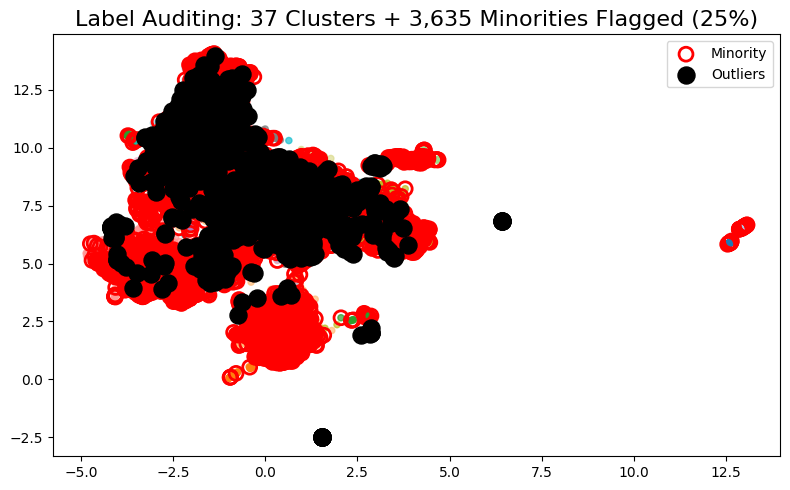

In [ ]:
## ONLY FOR VISUALISATION OF CLUSTERS
# Reduce to 2D for visualization (keep your tuned params!)
vis_umap = umap.UMAP(
    n_neighbors=15,
    n_components=2,  # 2D for plot
    min_dist=0.1,
    metric='cosine',
    random_state=42
)
embed_2d = vis_umap.fit_transform(embeddings)

# Plot with cluster colors + minority markers
plt.figure(figsize=(8, 5))
scatter = plt.scatter(embed_2d[:, 0], embed_2d[:, 1],
                     c=df['cluster'], cmap='tab20', s=20, alpha=0.7,
                     )

# Highlight minorities (red edges) + outliers (black)
minority_mask = df['is_minority']
outlier_mask = df['cluster'] == -1
plt.scatter(embed_2d[minority_mask, 0], embed_2d[minority_mask, 1],
           s=100, facecolors='none', edgecolors='red', linewidth=2, label='Minority')
plt.scatter(embed_2d[outlier_mask, 0], embed_2d[outlier_mask, 1],
           s=150, facecolors='black', label='Outliers')

plt.title('Label Auditing: ', fontsize=16)
plt.legend()
plt.tight_layout()
# plt.savefig('/content/drive/MyDrive/Label_Auditing_Project/cluster_visualization.png', dpi=300, bbox_inches='tight')
plt.show()


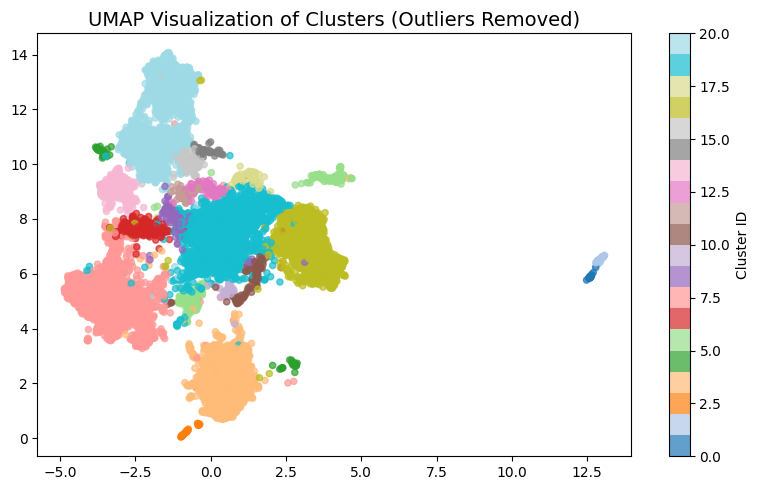

In [ ]:
# Show ONLY clusters (no outliers, no minority highlighting)

# Remove outliers

cluster_mask = df['cluster'] != -1

# Filter data

embed_clusters = embed_2d[cluster_mask]
cluster_labels = df.loc[cluster_mask, 'cluster']

# Plot clusters

plt.figure(figsize=(8, 5))
plt.scatter(embed_clusters[:, 0], embed_clusters[:, 1],
c=cluster_labels,
cmap='tab20',
s=20,
alpha=0.7)

plt.title('UMAP Visualization of Clusters (Outliers Removed)', fontsize=14)
plt.colorbar(label='Cluster ID')
plt.tight_layout()
plt.show()


In [ ]:
from sentence_transformers import CrossEncoder

In [ ]:
df.columns

Index(['airline_sentiment', 'text', 'clean_text', 'embedding', 'cluster',
       'is_minority'],
      dtype='object')

In [ ]:

# --- CROSS-ENCODER VALIDATION ---
ce_model = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")
label_desc = {
    "positive": "Positive sentiment, praise, or satisfaction.",
    "negative": "Negative sentiment, complaint, or disappointment.",
    "neutral": "Neutral, factual, or balanced statement."
}

def get_ce_margin(row):
    # Only run on suspicious samples to save time
     # Skip clean samples (saves 75% compute time!)
    if not row['is_minority'] and row['cluster'] != -1:
      return pd.Series({
        'ce_predicted_label': row['airline_sentiment'],
        'ce_margin': 1.0,
    }) # High confidence = "safe"

    # Score text against ALL 3 label descriptions
    pairs = [[row['clean_text'], desc] for desc in label_desc.values()]

    scores = ce_model.predict(pairs)## [0.05, 0.92, 0.23] = terrible text loves "negative"
    score_dict = dict(zip(label_desc.keys(), scores))# {'positive':0.05, 'negative':0.92, 'neutral':0.23}

    # Predicted label (highest score)
    predicted_label = max(score_dict, key=score_dict.get)

    assigned = score_dict[row['airline_sentiment']]# Given label score
    best_alt = max([v for k,v in score_dict.items() if k != row['airline_sentiment']])# Best other label
    margin = assigned - best_alt
    return pd.Series({
        'ce_predicted_label': predicted_label,
        'ce_margin': margin,
    })

df[['ce_predicted_label','ce_margin']] = df.apply(get_ce_margin, axis=1)

config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

In [ ]:
df.head()

,airline_sentiment,text,clean_text,embedding,cluster,is_minority,ce_predicted_label,ce_margin
0,neutral,@VirginAmerica What @dhepburn said.,@VirginAmerica What @dhepburn said.,"[-0.0155178225, 0.016140928, -0.0062406105, -0...",5,True,negative,-0.168569
1,positive,@VirginAmerica plus you've added commercials t...,@VirginAmerica plus you've added commercials t...,"[0.010883449, 0.070010535, -0.024289403, -0.05...",5,False,positive,1.000000
2,neutral,@VirginAmerica I didn't today... Must mean I n...,@VirginAmerica I didn't today... Must mean I n...,"[-0.014241995, 0.02331738, -0.037859295, -0.02...",5,True,negative,-0.183787
3,negative,@VirginAmerica it's really aggressive to blast...,@VirginAmerica it's really aggressive to blast...,"[0.0075340234, 0.016004702, -0.01237896, 0.019...",5,True,negative,0.340981
4,negative,@VirginAmerica and it's a really big bad thing...,@VirginAmerica and it's a really big bad thing...,"[0.025873858, 0.0136139095, -0.00562298, -0.04...",5,True,negative,0.095592


In [ ]:
# df.drop(columns=['audit_status'],axis=1,inplace=True)

In [ ]:
def audit_verdict(row):
    ##
    if row['ce_margin'] < -0.5 and row['is_minority'] and row['ce_predicted_label'] != row['airline_sentiment']:
        return "HIGH RISK (Mislabeled)"
    elif row['ce_margin'] < -0.5:
        return "MEDIUM RISK (Semantic Conflict)"
    elif row['is_minority']:
        return "MEDIUM RISK (Neighborhood Conflict)"
    elif row['cluster'] == -1:
        return "OUTLIER"
    return "SAFE"
df['audit_status'] = df.apply(audit_verdict, axis=1)

In [ ]:
df.head()

,airline_sentiment,text,clean_text,embedding,cluster,is_minority,ce_predicted_label,ce_margin,audit_status
0,neutral,@VirginAmerica What @dhepburn said.,@VirginAmerica What @dhepburn said.,"[-0.0155178225, 0.016140928, -0.0062406105, -0...",5,True,negative,-0.168569,MEDIUM RISK (Neighborhood Conflict)
1,positive,@VirginAmerica plus you've added commercials t...,@VirginAmerica plus you've added commercials t...,"[0.010883449, 0.070010535, -0.024289403, -0.05...",5,False,positive,1.000000,SAFE
2,neutral,@VirginAmerica I didn't today... Must mean I n...,@VirginAmerica I didn't today... Must mean I n...,"[-0.014241995, 0.02331738, -0.037859295, -0.02...",5,True,negative,-0.183787,MEDIUM RISK (Neighborhood Conflict)
3,negative,@VirginAmerica it's really aggressive to blast...,@VirginAmerica it's really aggressive to blast...,"[0.0075340234, 0.016004702, -0.01237896, 0.019...",5,True,negative,0.340981,MEDIUM RISK (Neighborhood Conflict)
4,negative,@VirginAmerica and it's a really big bad thing...,@VirginAmerica and it's a really big bad thing...,"[0.025873858, 0.0136139095, -0.00562298, -0.04...",5,True,negative,0.095592,MEDIUM RISK (Neighborhood Conflict)


In [ ]:
df.to_csv('/content/drive/MyDrive/final_adiited__complete_new.csv', index=False)

In [ ]:
print(df['audit_status'].value_counts())


audit_status
SAFE                                   8339
MEDIUM RISK (Neighborhood Conflict)    4454
OUTLIER                                1310
HIGH RISK (Mislabeled)                  268
MEDIUM RISK (Semantic Conflict)          48
Name: count, dtype: int64


In [ ]:
high_risk = df[df['audit_status'] == 'HIGH RISK (Mislabeled)']

high_risk.to_csv('high_risk_airline_audit_complete_final.csv', index=False)